In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

In [2]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root = "../data",
    train = True,
    download = True,
    transform = transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root = "../data",
    train = False,
    download = True,
    transform = transform
)

100.0%


In [3]:
print(len(train_dataset))
print(len(test_dataset))

50000
10000


In [4]:
print(train_dataset.classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [5]:
image, label = train_dataset[0]
print(image.shape)
print(label)

torch.Size([3, 32, 32])
6


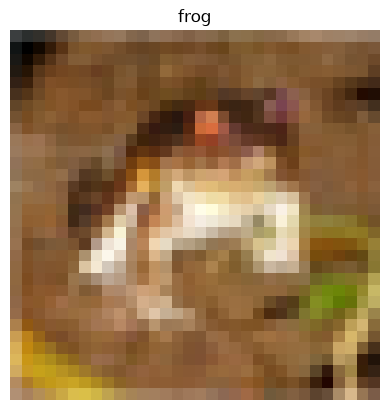

In [6]:
plt.imshow(image.permute(1,2,0))
plt.title(train_dataset.classes[label])
plt.axis("off")

plt.savefig("../images/train_dataset_classes.png")
plt.show()

In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [8]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)

    break

torch.Size([32, 3, 32, 32])
torch.Size([32])


In [10]:
import torch.nn as nn

class CNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(
            64*8*8,
            512
        )

        self.fc2 = nn.Linear(
            512,
            10
        )
    def forward(self, x):

        x = self.pool(
            self.relu(
                self.conv1(x)
            )
        )

        x = self.pool(
            self.relu(
                self.conv2(x)
            )
        )

        x = self.flatten(x)

        x = self.relu(
            self.fc1(x)
        )

        x = self.fc2(x)

        return x

In [ ]:
model = CNN()

print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


In [16]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [17]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(total_params)

2122186


In [14]:
model.train()

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)

In [18]:
epochs = 10
for epoch in range(epochs):
    running_loss = 0
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(
            outputs,
            labels
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )


Epoch 1/10, Loss: 1.4625
Epoch 2/10, Loss: 1.0823
Epoch 3/10, Loss: 0.9143
Epoch 4/10, Loss: 0.7927
Epoch 5/10, Loss: 0.6889
Epoch 6/10, Loss: 0.5910
Epoch 7/10, Loss: 0.5011
Epoch 8/10, Loss: 0.4144
Epoch 9/10, Loss: 0.3286
Epoch 10/10, Loss: 0.2613


In [19]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 67.93%


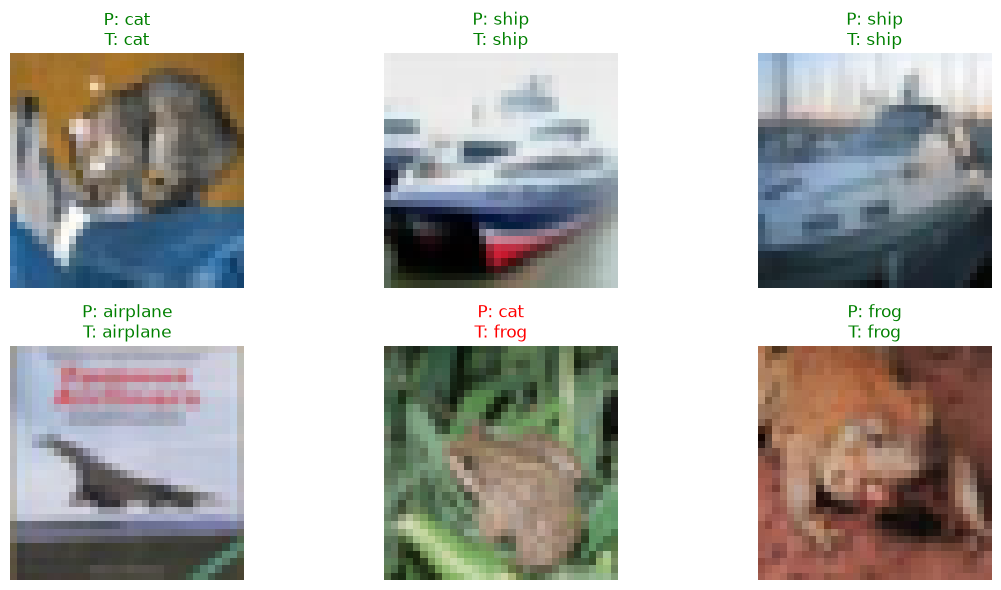

In [24]:
images, labels = next(iter(test_loader))

model.eval()

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

plt.figure(figsize=(12,6))

for i in range(6):
    plt.subplot(2,3,i+1)

    plt.imshow(
        images[i].permute(1,2,0),
        interpolation="nearest"
    )

    color = "green" if predicted[i] == labels[i] else "red"

    plt.title(
        f"P: {test_dataset.classes[predicted[i]]}\n"
        f"T: {test_dataset.classes[labels[i]]}",
        color=color
    )

    plt.axis("off")

plt.tight_layout()
plt.savefig("../images/test.png")
plt.show()

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [26]:
all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())

        all_predictions.extend(predicted.numpy())

In [27]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

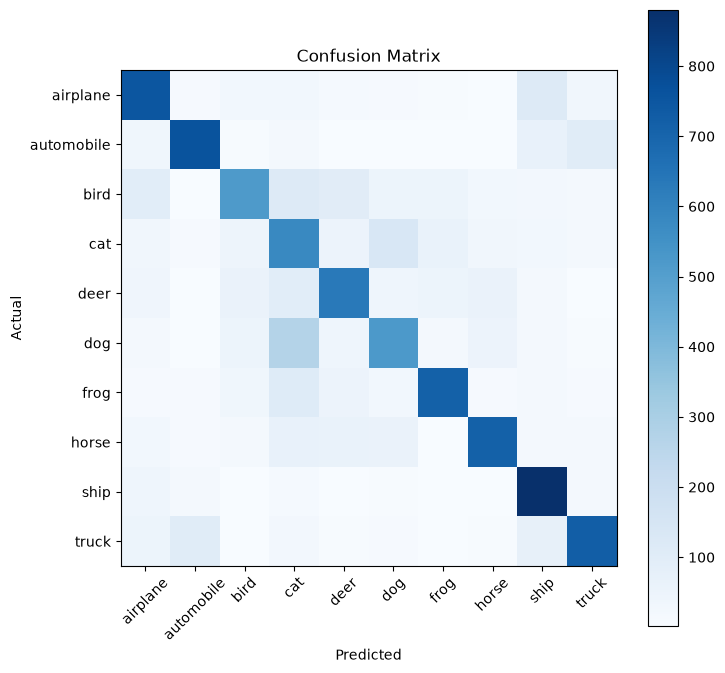

In [28]:
plt.figure(figsize=(8,8))

plt.imshow(
    cm,
    cmap="Blues"
)

plt.colorbar()

plt.xticks(
    range(10),
    train_dataset.classes,
    rotation=45
)

plt.yticks(
    range(10),
    train_dataset.classes
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig("../images/confusion_matrix.png")
plt.show()

In [30]:
torch.save(
    model.state_dict(),
    "../models/cnn_cifar10.pth"
)

print("Model Saved Successfully ✅")

Model Saved Successfully ✅


In [31]:
model = CNN()

In [32]:
model.load_state_dict(
    torch.load(
        "../models/cnn_cifar10.pth"
    )
)

model.eval()

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)

In [33]:
model.eval()

with torch.no_grad():

    outputs = model(images)

    _, predicted = torch.max(outputs,1)

print(predicted[:5])

tensor([7, 9, 8, 8, 8])
